In [34]:
import time
import copy
import numpy as np
import joblib
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from pathlib import Path
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.utils.class_weight import compute_sample_weight
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE


In [35]:
BASE_ENV = Path().resolve().parent
ART= BASE_ENV / 'artifacts'

In [36]:
X_train = np.load(ART / 'datasets/train/X.npy')
y_train = np.load(ART / 'datasets/train/y.npy')
X_val = np.load(ART / 'datasets/val/X.npy')
y_val = np.load(ART / 'datasets/val/y.npy')
X_test = np.load(ART / 'datasets/test/X.npy')
y_test = np.load(ART / 'datasets/test/y.npy')


In [37]:

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

X_train: (219973, 49)
y_train: (219973,)


In [38]:
encoder = joblib.load(ART / 'preprocessors/encoder.joblib')
num_of_classes = len(encoder.classes_)

In [39]:
print("Before SMOTE:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(encoder.inverse_transform(unique), counts):
    print(f"  {cls}: {cnt}")

# Define target counts for minority classes only
# Don't touch Benign and Generic — they're already huge
sampling_strategy = {}
target_counts = {
    'Rare_Attack':  9000,
    'Reconnaissance' : 12000
}

Before SMOTE:
  Benign: 125416
  DoS: 34976
  Exploits: 21539
  Fuzzers: 20987
  Rare_Attack: 5394
  Reconnaissance: 11661


In [40]:
for cls, target in target_counts.items():
    if cls in encoder.classes_:
        encoded_label = encoder.transform([cls])[0]
        current_count = np.sum(y_train == encoded_label)
        if current_count < target:
            sampling_strategy[encoded_label] = target


In [41]:
sm = SMOTE(
    sampling_strategy=sampling_strategy,
    random_state=42,
    k_neighbors=3  # small because some classes have very few samples
)

In [42]:
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [43]:
print("\nAfter SMOTE:")
unique, counts = np.unique(y_train_res, return_counts=True)
for cls, cnt in zip(encoder.inverse_transform(unique), counts):
    print(f"  {cls}: {cnt}")


After SMOTE:
  Benign: 125416
  DoS: 34976
  Exploits: 21539
  Fuzzers: 20987
  Rare_Attack: 9000
  Reconnaissance: 12000


In [44]:
X_proto, _, y_proto, _ = train_test_split(
    X_train_res, y_train_res, 
    train_size=0.05,           # Keep exactly 5%
    stratify=y_train_res,  # CRITICAL: Maintain the exact ratio of attack types
    random_state=42
)

In [45]:
param_grid = {
    'max_depth': [3, 6, 9, 12, 16],              # Shallow vs Deep trees
    'learning_rate': [0.001, 0.01, 0.1, 0.3],   # Slow vs Fast learning
    'n_estimators': [50, 100, 200, 400],      # Number of trees
    'subsample': [0.5, 0.8, 1.0]              # Prevent overfitting by using 80% of data per tree
}

In [22]:
xgb_tuner = XGBClassifier(objective='multi:softprob', random_state=42, n_jobs=2)

# Set up the search engine
random_search = RandomizedSearchCV(
    estimator=xgb_tuner,
    param_distributions=param_grid,
    n_iter=20,             # Test exactly 10 random combinations from the menu
    scoring='accuracy',
    cv=3,                  # Cross-validation: double checks the score 3 times per test
    verbose=2,             # Prints progress so you aren't staring at a blank screen
    random_state=42,
    n_jobs=2                # Use all CPU cores
)

In [46]:
random_search.fit(X_proto, y_proto)
print("Best Hyperparameters:", random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END learning_rate=0.001, max_depth=9, n_estimators=50, subsample=0.5; total time=   0.7s
[CV] END learning_rate=0.001, max_depth=9, n_estimators=50, subsample=0.5; total time=   0.7s
[CV] END learning_rate=0.001, max_depth=9, n_estimators=50, subsample=0.5; total time=   0.5s
[CV] END learning_rate=0.001, max_depth=3, n_estimators=200, subsample=0.5; total time=   0.8s
[CV] END learning_rate=0.001, max_depth=3, n_estimators=200, subsample=0.5; total time=   0.8s
[CV] END learning_rate=0.001, max_depth=3, n_estimators=200, subsample=0.5; total time=   0.9s


KeyboardInterrupt: 

In [47]:
xgb_final = XGBClassifier(
    objective='multi:softprob', 
    num_class=num_of_classes,
    max_depth=9,             # Injected from Tuner
    learning_rate=0.01,       # Injected from Tuner
    n_estimators=200,         # Injected from Tuner
    subsample=1.0,           # Injected from Tuner
    random_state=42,
    n_jobs=-1                # Use all CPU cores
)

In [48]:
xgb_final.fit(X_train_res, y_train_res)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [49]:
y_pred = xgb_final.predict(X_test)

In [50]:
y_test_labels = encoder.inverse_transform(y_test)
y_pred_labels = encoder.inverse_transform(y_pred)

In [51]:
print(f"DoS in test: {(y_test_labels == 'DoS').sum()}")
print(f"Total test: {len(y_test_labels)}")

DoS in test: 10043
Total test: 62901


In [52]:
accuracy_score(y_test_labels, y_pred_labels)

0.9187135339660737

In [53]:
print("\nDetailed Classification Report:")
print(classification_report(y_test_labels, y_pred_labels, digits=4))


Detailed Classification Report:
                precision    recall  f1-score   support

        Benign     0.9972    0.9630    0.9798     35834
           DoS     0.9990    1.0000    0.9995     10043
      Exploits     0.8535    0.7602    0.8041      6238
       Fuzzers     0.5917    0.9367    0.7252      5782
   Rare_Attack     0.7751    0.5421    0.6380      1640
Reconnaissance     0.9174    0.6507    0.7614      3364

      accuracy                         0.9187     62901
     macro avg     0.8556    0.8088    0.8180     62901
  weighted avg     0.9359    0.9187    0.9215     62901



In [54]:
param_grid = {
    'max_depth':        [3, 6, 9],
    'learning_rate':    [0.01, 0.1, 0.3],
    'n_estimators':     [50, 100, 200],
    'subsample':        [0.8, 1.0],
    'num_leaves':       [31, 63, 127],  # LightGBM specific — controls tree complexity
    'class_weight':     ['balanced', None]            # Prevent overfitting by using 80% of data per tree
}

In [58]:
lgbm_tuner = LGBMClassifier(objective='multiclass', random_state=42, n_jobs=2)

random_search = RandomizedSearchCV(
    estimator=lgbm_tuner,
    param_distributions=param_grid,
    n_iter=10,
    scoring='accuracy',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=2
)

In [59]:
random_search.fit(X_proto, y_proto)
print("Best Hyperparameters:", random_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001107 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001285 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9328
[LightGBM] [Info] Total Bins 9341
[LightGBM] [Info] Number of data points in the train set: 7463, number of used features: 49
[LightGBM] [Info] Number of data points in the train set: 7463, number of used features: 49
[LightGBM] [Info] Start training from score -1.791759[LightGBM] [Info] Start training from score -1.791759

[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] S

/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=balanced, learning_rate=0.3, max_depth=6, n_estimators=100, num_leaves=31, subsample=0.8; total time=   0.7s
[CV] END class_weight=balanced, learning_rate=0.3, max_depth=6, n_estimators=100, num_leaves=31, subsample=0.8; total time=   0.7s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000376 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9359
[LightGBM] [Info] Number of data points in the train set: 7464, number of used features: 49
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the 

/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000526 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Total Bins 9359
[LightGBM] [Info] Number of data points in the train set: 7464, number of used features: 49
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000459 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9359
[LightGBM] [Info] Number of data points in the train set: 7464, number of used features: 49
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=None, learning_rate=0.01, max_depth=6, n_estimators=50, num_leaves=31, subsample=0.8; total time=   0.4s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000413 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9359
[LightGBM] [Info] Number of data points in the train set: 7464, number of used features: 49
[LightGBM] [Info] Start training from score -0.579780
[LightGBM] [Info] Start training from score -1.856512
[LightGBM] [Info] Start training from score -2.341377
[LightGBM] [Info] Start training from score -2.366766
[LightGBM] [Info] Start training from score -3.214064
[LightGBM] [Info] Start training from score -2.926382
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with pos

/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[CV] END class_weight=balanced, learning_rate=0.3, max_depth=9, n_estimators=50, num_leaves=31, subsample=0.8; total time=   0.3s
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with p

/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [60]:
lgbm_final = LGBMClassifier(
    objective='multiclass',
    num_class=num_of_classes,
    subsample=0.8,
    num_leaves=127,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.01,
    random_state=42,
    n_jobs=-1
)

In [61]:
lgbm_final.fit(X_train_res, y_train_res)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035856 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11147
[LightGBM] [Info] Number of data points in the train set: 223918, number of used features: 49
[LightGBM] [Info] Start training from score -0.579644
[LightGBM] [Info] Start training from score -1.856618
[LightGBM] [Info] Start training from score -2.341415
[LightGBM] [Info] Start training from score -2.367377
[LightGBM] [Info] Start training from score -3.214055
[LightGBM] [Info] Start training from score -2.926373
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] 

,boosting_type,'gbdt'
,num_leaves,127
,max_depth,6
,learning_rate,0.01
,n_estimators,200
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [62]:
y_pred = lgbm_final.predict(X_test)

/home/hassan/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [63]:
y_test_labels = encoder.inverse_transform(y_test)
y_pred_labels = encoder.inverse_transform(y_pred)

In [64]:
accuracy_score(y_test_labels, y_pred_labels)

0.9107963307419595

In [65]:
print("\nDetailed Classification Report:")
print(classification_report(y_test_labels, y_pred_labels, digits=4))


Detailed Classification Report:
                precision    recall  f1-score   support

        Benign     0.9999    0.9554    0.9771     35834
           DoS     1.0000    1.0000    1.0000     10043
      Exploits     0.8324    0.7435    0.7854      6238
       Fuzzers     0.5659    0.9348    0.7050      5782
   Rare_Attack     0.7275    0.4738    0.5739      1640
Reconnaissance     0.9035    0.6510    0.7567      3364

      accuracy                         0.9108     62901
     macro avg     0.8382    0.7931    0.7997     62901
  weighted avg     0.9311    0.9108    0.9145     62901



In [66]:
xgb_final.save_model(ART / 'models/xgb_NUSW-NB15.json')

Top 10 Features Driving the 100% Accuracy:
                   Feature  Importance
13          Flow_Packets_s    0.224374
30           Bwd_Packets_s    0.147386
46      Bwd_Init_Win_Bytes    0.130373
38           Down_Up_Ratio    0.110143
48        Fwd_Seg_Size_Min    0.100454
35          FIN_Flag_Count    0.067981
36          PSH_Flag_Count    0.041812
31       Packet_Length_Min    0.016735
33      Packet_Length_Mean    0.015297
10  Bwd_Packet_Length_Mean    0.014946


/tmp/ipykernel_24211/3233241745.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


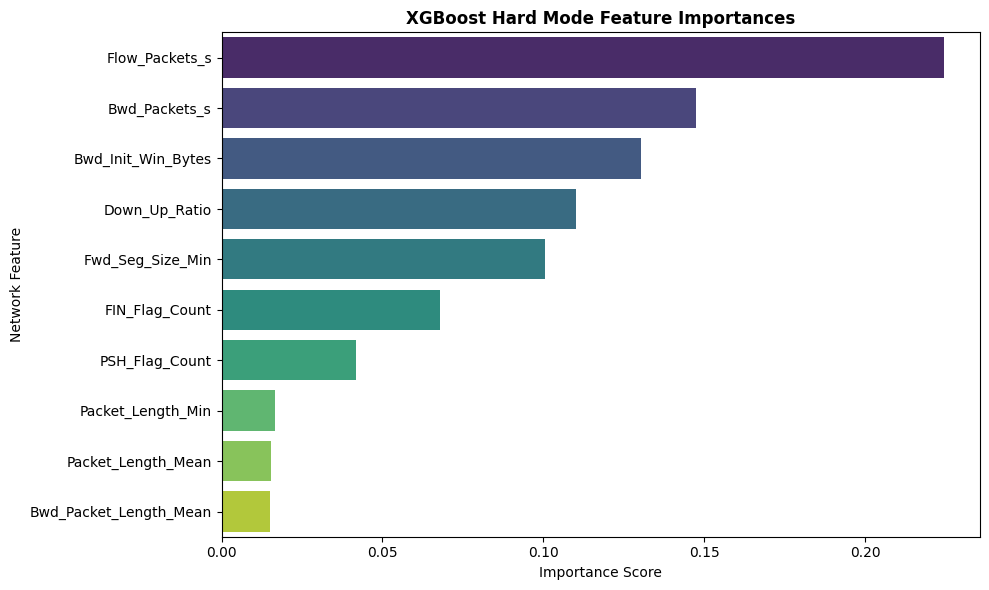

In [57]:
# The exact 41 features that survived the Hard Mode purge
hard_mode_features =[ 'Flow_Duration', 'Total_Fwd_Packet',
       'Total_Bwd_packets', 'Total_Length_of_Fwd_Packet',
       'Total_Length_of_Bwd_Packet', 'Fwd_Packet_Length_Max',
       'Fwd_Packet_Length_Min', 'Fwd_Packet_Length_Mean',
       'Bwd_Packet_Length_Max', 'Bwd_Packet_Length_Min',
       'Bwd_Packet_Length_Mean', 'Bwd_Packet_Length_Std', 'Flow_Bytes_s',
       'Flow_Packets_s', 'Flow_IAT_Mean', 'Flow_IAT_Std', 'Flow_IAT_Max',
       'Fwd_IAT_Total', 'Fwd_IAT_Mean', 'Fwd_IAT_Std', 'Fwd_IAT_Max',
       'Fwd_IAT_Min', 'Bwd_IAT_Total', 'Bwd_IAT_Mean', 'Bwd_IAT_Std',
       'Bwd_IAT_Max', 'Bwd_IAT_Min', 'Fwd_Header_Length', 'Bwd_Header_Length',
       'Fwd_Packets_s', 'Bwd_Packets_s', 'Packet_Length_Min',
       'Packet_Length_Max', 'Packet_Length_Mean', 'Packet_Length_Std',
       'FIN_Flag_Count', 'PSH_Flag_Count', 'ACK_Flag_Count', 'Down_Up_Ratio',
       'Average_Packet_Size', 'Fwd_Segment_Size_Avg', 'Bwd_Segment_Size_Avg',
       'Bwd_Bytes_Bulk_Avg', 'Bwd_Packet_Bulk_Avg', 'Bwd_Bulk_Rate_Avg',
       'FWD_Init_Win_Bytes', 'Bwd_Init_Win_Bytes', 'Fwd_Act_Data_Pkts',
       'Fwd_Seg_Size_Min']

# Safety check to ensure the array shape matches the name list
if X_train.shape[1] != len(hard_mode_features):
    print(f"WARNING: Feature count mismatch! Array has {X_train.shape[1]} columns, but list has {len(hard_mode_features)}.")
else:
    # Extract the importance scores from your Hard Mode model
    importances = xgb_final.feature_importances_

    # Map the scores using our hardcoded list instead of df.columns
    feature_importance_df = pd.DataFrame({
        'Feature': hard_mode_features,
        'Importance': importances
    })

    # Sort to find the new "Cheat Codes"
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    print("Top 10 Features Driving the 100% Accuracy:")
    print(feature_importance_df.head(10))

    # Visualize it
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x='Importance', 
        y='Feature', 
        data=feature_importance_df.head(10), 
        palette='viridis'
    )
    plt.title('XGBoost Hard Mode Feature Importances', fontweight='bold')
    plt.xlabel('Importance Score')
    plt.ylabel('Network Feature')
    plt.tight_layout()
    plt.show()

Top 10 Features Driving the 100% Accuracy:
                       Feature  Importance
30               Bwd_Packets_s        3214
5        Fwd_Packet_Length_Max        3153
3   Total_Length_of_Fwd_Packet        2961
8        Bwd_Packet_Length_Max        2334
45          FWD_Init_Win_Bytes        2230
4   Total_Length_of_Bwd_Packet        2197
48            Fwd_Seg_Size_Min        2136
36              PSH_Flag_Count        2066
13              Flow_Packets_s        1733
0                Flow_Duration        1710


/tmp/ipykernel_24211/1942855608.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


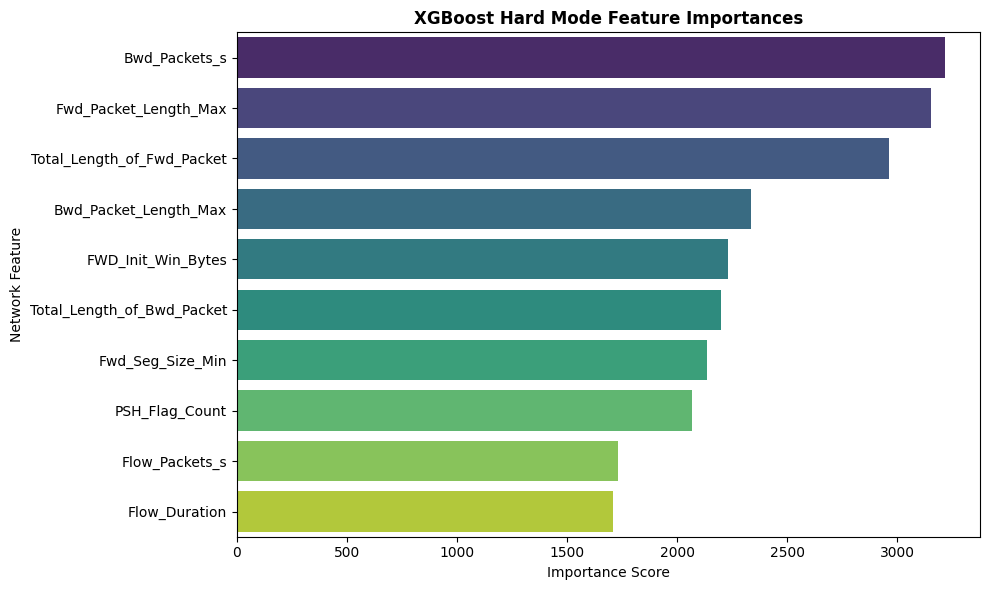

In [69]:
# The exact 41 features that survived the Hard Mode purge
hard_mode_features = [ 'Flow_Duration', 'Total_Fwd_Packet',
       'Total_Bwd_packets', 'Total_Length_of_Fwd_Packet',
       'Total_Length_of_Bwd_Packet', 'Fwd_Packet_Length_Max',
       'Fwd_Packet_Length_Min', 'Fwd_Packet_Length_Mean',
       'Bwd_Packet_Length_Max', 'Bwd_Packet_Length_Min',
       'Bwd_Packet_Length_Mean', 'Bwd_Packet_Length_Std', 'Flow_Bytes_s',
       'Flow_Packets_s', 'Flow_IAT_Mean', 'Flow_IAT_Std', 'Flow_IAT_Max',
       'Fwd_IAT_Total', 'Fwd_IAT_Mean', 'Fwd_IAT_Std', 'Fwd_IAT_Max',
       'Fwd_IAT_Min', 'Bwd_IAT_Total', 'Bwd_IAT_Mean', 'Bwd_IAT_Std',
       'Bwd_IAT_Max', 'Bwd_IAT_Min', 'Fwd_Header_Length', 'Bwd_Header_Length',
       'Fwd_Packets_s', 'Bwd_Packets_s', 'Packet_Length_Min',
       'Packet_Length_Max', 'Packet_Length_Mean', 'Packet_Length_Std',
       'FIN_Flag_Count', 'PSH_Flag_Count', 'ACK_Flag_Count', 'Down_Up_Ratio',
       'Average_Packet_Size', 'Fwd_Segment_Size_Avg', 'Bwd_Segment_Size_Avg',
       'Bwd_Bytes_Bulk_Avg', 'Bwd_Packet_Bulk_Avg', 'Bwd_Bulk_Rate_Avg',
       'FWD_Init_Win_Bytes', 'Bwd_Init_Win_Bytes', 'Fwd_Act_Data_Pkts',
       'Fwd_Seg_Size_Min']
      

# Safety check to ensure the array shape matches the name list
if X_train.shape[1] != len(hard_mode_features):
    print(f"WARNING: Feature count mismatch! Array has {X_train.shape[1]} columns, but list has {len(hard_mode_features)}.")
else:
    # Extract the importance scores from your Hard Mode model
    importances = lgbm_final.feature_importances_

    # Map the scores using our hardcoded list instead of df.columns
    feature_importance_df = pd.DataFrame({
        'Feature': hard_mode_features,
        'Importance': importances
    })

    # Sort to find the new "Cheat Codes"
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    print("Top 10 Features Driving the 100% Accuracy:")
    print(feature_importance_df.head(10))

    # Visualize it
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x='Importance', 
        y='Feature', 
        data=feature_importance_df.head(10), 
        palette='viridis'
    )
    plt.title('XGBoost Hard Mode Feature Importances', fontweight='bold')
    plt.xlabel('Importance Score')
    plt.ylabel('Network Feature')
    plt.tight_layout()
    plt.show()

In [70]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
X_train_tensor = torch.tensor(X_train_res, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_res, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [74]:
batch_size = 256
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

validation_dataset = TensorDataset(X_val_tensor, y_val_tensor)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [75]:
class IDSNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(IDSNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2)

        self.fc2 = nn.Linear(hidden_dim, hidden_dim//2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)  

        self.output_layer = nn.Linear(hidden_dim//2, output_dim)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        x = self.output_layer(x)
        return x

In [76]:
input_dim = X_train.shape[1]
hidden_dim = 128
output_dim = num_of_classes
model = IDSNN(input_dim, hidden_dim, output_dim).to(device)

In [77]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [78]:
epochs = 50
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

Epoch 1/50, Loss: 0.5269
Epoch 2/50, Loss: 0.3522
Epoch 3/50, Loss: 0.3326
Epoch 4/50, Loss: 0.3183
Epoch 5/50, Loss: 0.3079
Epoch 6/50, Loss: 0.2998
Epoch 7/50, Loss: 0.2936
Epoch 8/50, Loss: 0.2891
Epoch 9/50, Loss: 0.2846
Epoch 10/50, Loss: 0.2815
Epoch 11/50, Loss: 0.2790
Epoch 12/50, Loss: 0.2766
Epoch 13/50, Loss: 0.2737
Epoch 14/50, Loss: 0.2716
Epoch 15/50, Loss: 0.2688
Epoch 16/50, Loss: 0.2676
Epoch 17/50, Loss: 0.2654
Epoch 18/50, Loss: 0.2631
Epoch 19/50, Loss: 0.2623
Epoch 20/50, Loss: 0.2598
Epoch 21/50, Loss: 0.2583
Epoch 22/50, Loss: 0.2570
Epoch 23/50, Loss: 0.2548
Epoch 24/50, Loss: 0.2544
Epoch 25/50, Loss: 0.2531
Epoch 26/50, Loss: 0.2523
Epoch 27/50, Loss: 0.2516
Epoch 28/50, Loss: 0.2506
Epoch 29/50, Loss: 0.2504
Epoch 30/50, Loss: 0.2493
Epoch 31/50, Loss: 0.2481
Epoch 32/50, Loss: 0.2481
Epoch 33/50, Loss: 0.2470
Epoch 34/50, Loss: 0.2468
Epoch 35/50, Loss: 0.2456
Epoch 36/50, Loss: 0.2451
Epoch 37/50, Loss: 0.2445
Epoch 38/50, Loss: 0.2441
Epoch 39/50, Loss: 0.

In [79]:
model.eval()

IDSNN(
  (fc1): Linear(in_features=49, out_features=128, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.2, inplace=False)
  (output_layer): Linear(in_features=64, out_features=6, bias=True)
)

In [80]:
all_predictions, all_true_labels = [], []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        # Move test batch to GPU
        batch_X = batch_X.to(device)
        
        # Get raw mathematical outputs (logits) from the network
        outputs = model(batch_X)
        
        # Find the neuron with the highest probability (the prediction)
        # torch.max returns both the value and the index. We only want the index [1]
        _, predicted_classes = torch.max(outputs, 1)
        
        # Move predictions back to the CPU memory to work with Scikit-Learn
        all_predictions.extend(predicted_classes.cpu().numpy())
        all_true_labels.extend(batch_y.numpy())

y_test_labels = encoder.inverse_transform(all_true_labels)
y_pred_labels = encoder.inverse_transform(all_predictions)

In [81]:
accuracy_score(y_test_labels, y_pred_labels)

0.9014642056565079

In [82]:
print(classification_report(y_test_labels, y_pred_labels, digits=4))

                precision    recall  f1-score   support

        Benign     0.9999    0.9554    0.9771     35834
           DoS     0.9997    0.9997    0.9997     10043
      Exploits     0.8426    0.6917    0.7597      6238
       Fuzzers     0.5283    0.9204    0.6713      5782
   Rare_Attack     0.6524    0.4372    0.5235      1640
Reconnaissance     0.8924    0.6165    0.7293      3364

      accuracy                         0.9015     62901
     macro avg     0.8192    0.7702    0.7768     62901
  weighted avg     0.9261    0.9015    0.9060     62901



In [83]:
torch.save(model.state_dict(), ART / 'models/dnn_UNSW-NB15.pth')

In [84]:
def create_sliding_windows(X, y, window_size=5):
    X_windows, y_windows = [], []
    for i in range(len(X) - window_size + 1):
        X_windows.append(X[i:i+window_size])
        y_windows.append(y[i+window_size-1])  # Label of the last item in the window
    return np.array(X_windows), np.array(y_windows)

In [85]:
X_train_windows, y_train_windows = create_sliding_windows(X_train_res, y_train_res, window_size=10)
X_val_windows, y_val_windows = create_sliding_windows(X_val, y_val, window_size=10)

In [86]:
X_train_windows.shape

(223909, 10, 49)

In [87]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [88]:
X_train_tensor = torch.tensor(X_train_windows, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_windows, dtype=torch.long).to(device)

X_val_tensor = torch.tensor(X_val_windows, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val_windows, dtype=torch.long).to(device)

In [89]:
batch_size = 256
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_dataset = TensorDataset(X_val_tensor, y_val_tensor)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

In [90]:
class IDSNN_LSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2):
        super(IDSNN_LSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0.0
            )
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        lstm_out = lstm_out[:, -1, :]  # Take the output of the last time step
        lstm_out = self.fc(lstm_out)
        return lstm_out

In [91]:
input_dim = X_train_windows.shape[2]  
hidden_dim = 128
output_dim = num_of_classes
model = IDSNN_LSTM(input_dim, hidden_dim, output_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [92]:
EPOCHS = 100
PATIENCE = 5

best_val_loss = float('inf')
patience_counter = 0
best_model_state = copy.deepcopy(model.state_dict())

In [93]:
start_time = time.time()

for epoch in range(EPOCHS):
    epoch_time = time.time()

    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in validation_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(validation_loader)

    epoch_duration = time.time() - epoch_time
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Time: {epoch_duration:.2f}s")
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, ART / 'models/best_idsnn_lstm.pth')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping triggered!")
            break
total_training_time = (time.time() - start_time) / 60
print(f"Total Training Time: {total_training_time:.2f} minutes")

Epoch 1/100 - Loss: 0.6037, Val Loss: 0.4330, Time: 3.48s
Epoch 2/100 - Loss: 0.3580, Val Loss: 0.3928, Time: 3.29s
Epoch 3/100 - Loss: 0.3285, Val Loss: 0.3822, Time: 3.55s
Epoch 4/100 - Loss: 0.3188, Val Loss: 0.3622, Time: 3.31s
Epoch 5/100 - Loss: 0.3110, Val Loss: 0.3549, Time: 3.29s
Epoch 6/100 - Loss: 0.3020, Val Loss: 0.3479, Time: 3.45s
Epoch 7/100 - Loss: 0.2904, Val Loss: 0.3278, Time: 5.11s
Epoch 8/100 - Loss: 0.2798, Val Loss: 0.3186, Time: 3.45s
Epoch 9/100 - Loss: 0.2716, Val Loss: 0.3154, Time: 3.34s
Epoch 10/100 - Loss: 0.2660, Val Loss: 0.3108, Time: 3.46s
Epoch 11/100 - Loss: 0.2617, Val Loss: 0.3121, Time: 3.36s
Epoch 12/100 - Loss: 0.2580, Val Loss: 0.3074, Time: 3.48s
Epoch 13/100 - Loss: 0.2551, Val Loss: 0.2988, Time: 3.38s
Epoch 14/100 - Loss: 0.2533, Val Loss: 0.2943, Time: 3.42s
Epoch 15/100 - Loss: 0.2512, Val Loss: 0.2952, Time: 3.61s
Epoch 16/100 - Loss: 0.2488, Val Loss: 0.3023, Time: 3.39s
Epoch 17/100 - Loss: 0.2470, Val Loss: 0.2976, Time: 5.31s
Epoch 

In [94]:
X_test_windows, y_test_windows = create_sliding_windows(X_test, y_test, window_size=10) 
X_test_tensor = torch.tensor(X_test_windows, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_windows, dtype=torch.long)

In [95]:
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [96]:
model.load_state_dict(torch.load(ART / 'models/best_idsnn_lstm.pth'))
model.to(device)

IDSNN_LSTM(
  (lstm): LSTM(49, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=6, bias=True)
)

In [97]:
model.eval()

IDSNN_LSTM(
  (lstm): LSTM(49, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=6, bias=True)
)

In [98]:
lstm_predictions, lstm_true_labels = [], []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        _, predicted_classes = torch.max(outputs, 1)
        lstm_predictions.extend(predicted_classes.cpu().numpy())
        lstm_true_labels.extend(batch_y.numpy())
lstm_true_labels = encoder.inverse_transform(lstm_true_labels)
lstm_pred_labels = encoder.inverse_transform(lstm_predictions)

In [99]:
accuracy_score(lstm_true_labels, lstm_pred_labels)

0.8863289448578515

In [100]:
print(classification_report(lstm_true_labels, lstm_pred_labels, digits=4))

                precision    recall  f1-score   support

        Benign     0.9989    0.9551    0.9765     35829
           DoS     0.9986    0.9997    0.9992     10040
      Exploits     0.7818    0.6791    0.7268      6238
       Fuzzers     0.4945    0.8684    0.6301      5782
   Rare_Attack     0.8153    0.2530    0.3862      1640
Reconnaissance     0.7247    0.5394    0.6185      3363

      accuracy                         0.8863     62892
     macro avg     0.8023    0.7158    0.7229     62892
  weighted avg     0.9115    0.8863    0.8890     62892



In [ ]:
old_file = ART / 'models/best_idsnn_lstm.pth'
new_file = ART / 'models/lstm_UNSW-NB15.pth'

if old_file.exists():
    old_file.rename(new_file)
    print(f"Successfully renamed to: {new_file.name}")
else:
    print("The old file does not exist. It may have already been renamed.")